In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [2]:
sleep_df = pd.read_csv("/kaggle/input/sleep-health-and-lifestyle-dataset/Sleep_health_and_lifestyle_dataset.csv")
sleep_df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [3]:
sleep_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [4]:
sleep_df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [5]:
sleep_df.dropna()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
16,17,Female,29,Nurse,6.5,5,40,7,Normal Weight,132/87,80,4000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [6]:
missing_values_after_drop_sleep = sleep_df.isnull().sum()

In [7]:
summary_stats_sleep = sleep_df.describe()
summary_stats_sleep

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


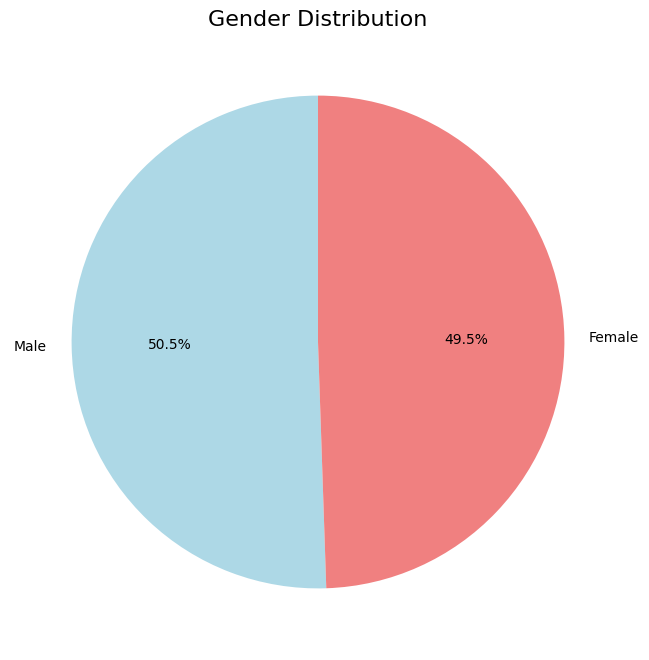

In [8]:
plt.figure(figsize=(8, 8))
gender_counts = sleep_df['Gender'].value_counts()

plt.pie(gender_counts, 
        labels=gender_counts.index, 
        autopct='%1.1f%%', 
        colors=['lightblue', 'lightcoral'], 
        startangle=90)

plt.title('Gender Distribution', fontsize=16)

plt.show()


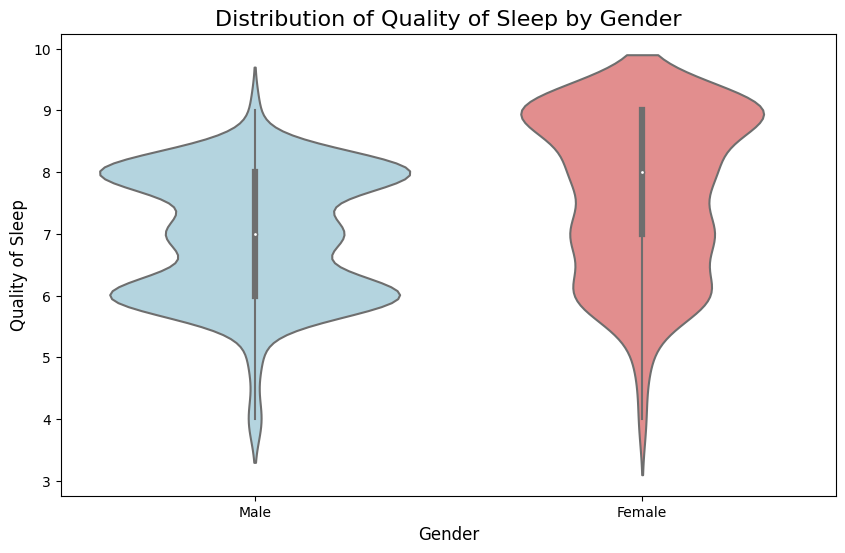

In [9]:
color_palette = {'Male': 'lightblue', 'Female': 'lightcoral'}
plt.figure(figsize=(10, 6))
sns.violinplot(x='Gender', y='Quality of Sleep', data=sleep_df, palette=color_palette)
plt.title('Distribution of Quality of Sleep by Gender', fontsize=16)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Quality of Sleep', fontsize=12)
plt.show()

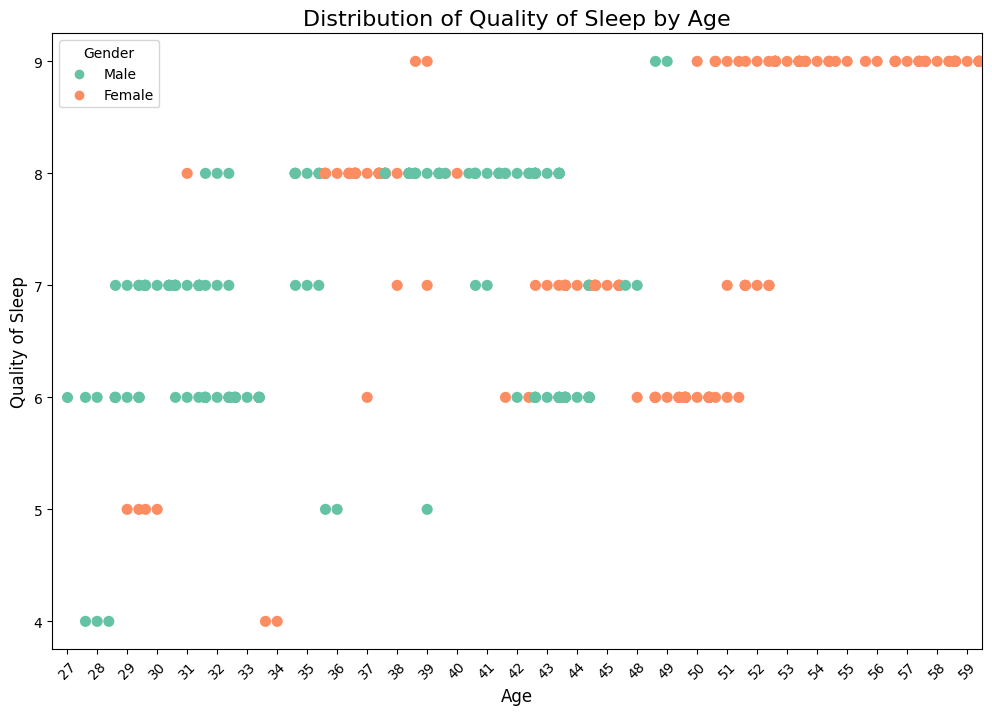

In [10]:
color_palette = sns.color_palette('Set2')
plt.figure(figsize=(12, 8))
sns.swarmplot(x='Age', 
              y='Quality of Sleep', 
              hue='Gender', 
              data=sleep_df, 
              palette=color_palette, 
              size=8)
plt.title('Distribution of Quality of Sleep by Age', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Quality of Sleep', fontsize=12)
plt.legend(title='Gender', fontsize=10)
plt.xticks(rotation=45)
plt.show()

In [11]:
fig = px.scatter(sleep_df, 
                 x='Daily Steps', 
                 y='Gender', 
                 color='Gender',
                 title='Relationship between Daily Steps and Gender')
fig.show()

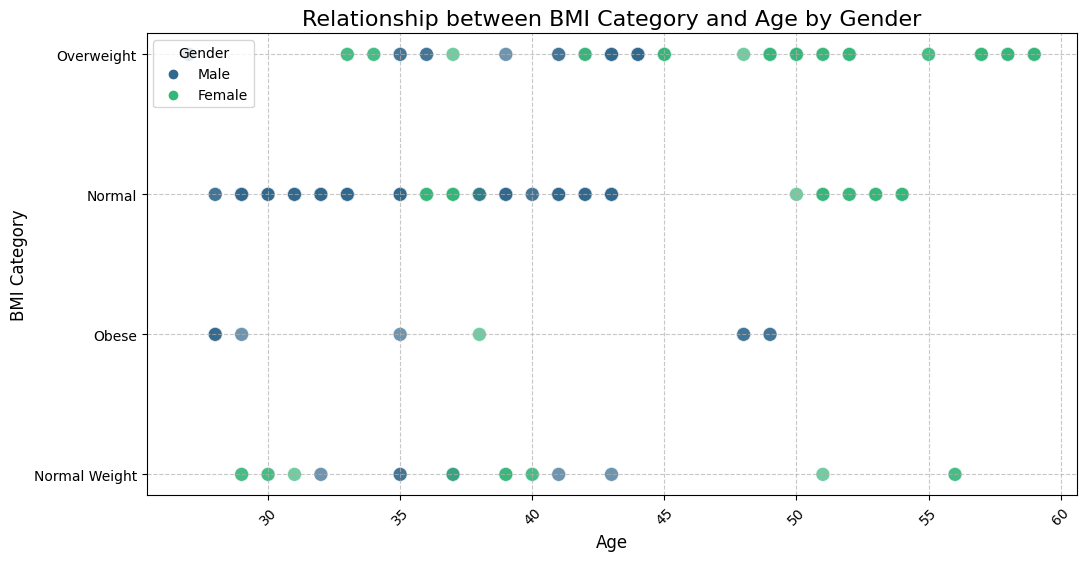

In [12]:

plt.figure(figsize=(12, 6))

scatter_plot = sns.scatterplot(x='Age', 
                               y='BMI Category', 
                               data=sleep_df, 
                               hue='Gender', 
                               palette='viridis', 
                               s=100,
                               edgecolor='w', 
                               alpha=0.7, 
                               linewidth=0.5)
plt.xticks(rotation=45)

plt.title('Relationship between BMI Category and Age by Gender', 
          fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('BMI Category', fontsize=12)
plt.legend(title='Gender', fontsize=10, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()


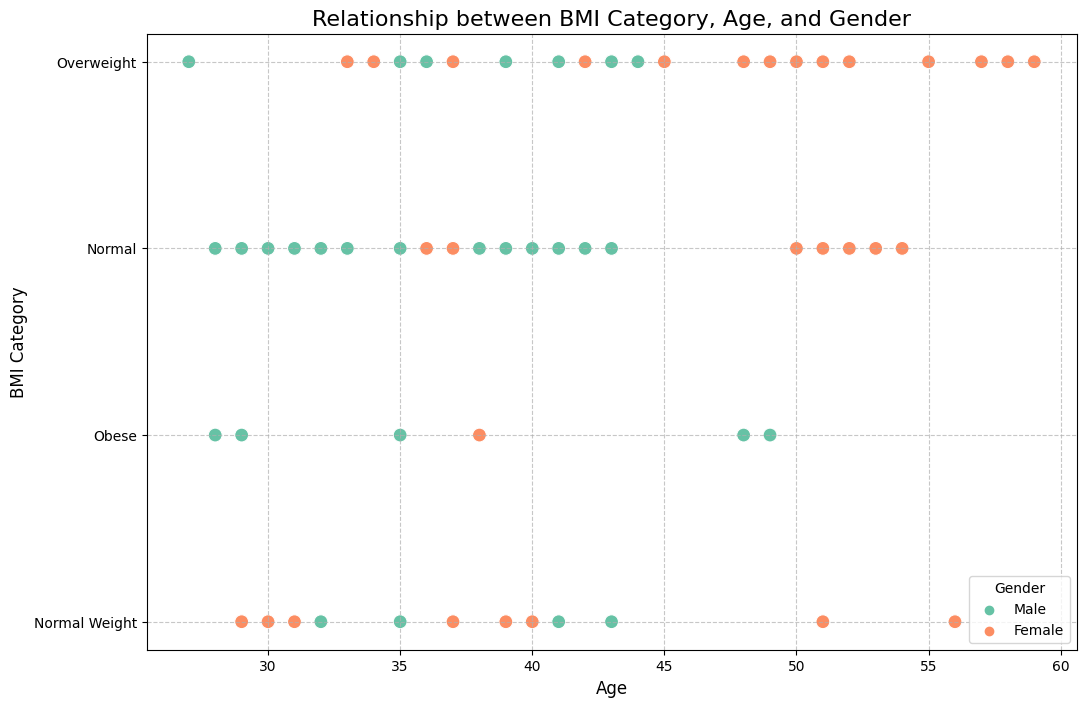

In [13]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Age', 
                y='BMI Category', 
                hue='Gender', 
                data=sleep_df, 
                palette=color_palette, s=100)
plt.title('Relationship between BMI Category, Age, and Gender', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('BMI Category', fontsize=12)
plt.legend(title='Gender', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


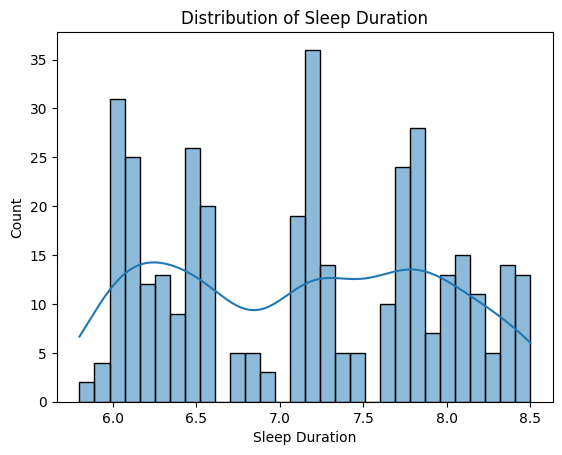

In [14]:
sns.histplot(sleep_df['Sleep Duration'], bins=30, kde=True)
plt.title('Distribution of Sleep Duration')
plt.show()

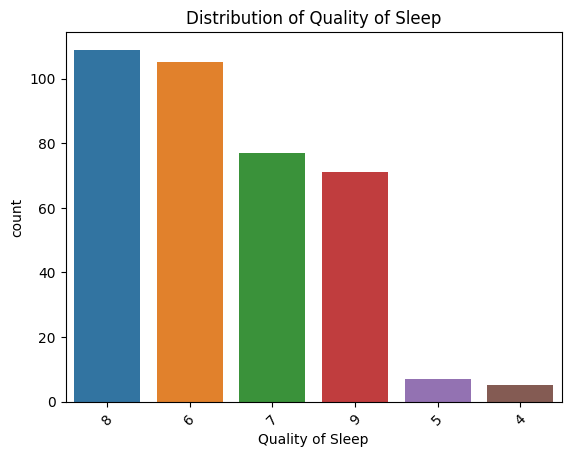

In [15]:
sns.countplot(x='Quality of Sleep', data=sleep_df, order=sleep_df['Quality of Sleep'].value_counts().index)
plt.title('Distribution of Quality of Sleep')
plt.xticks(rotation=45)
plt.show()


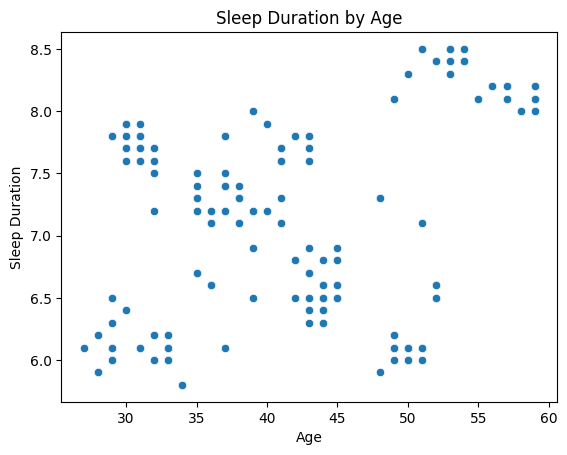

In [16]:
sns.scatterplot(x='Age', y='Sleep Duration', data=sleep_df)
plt.title('Sleep Duration by Age')
plt.show()

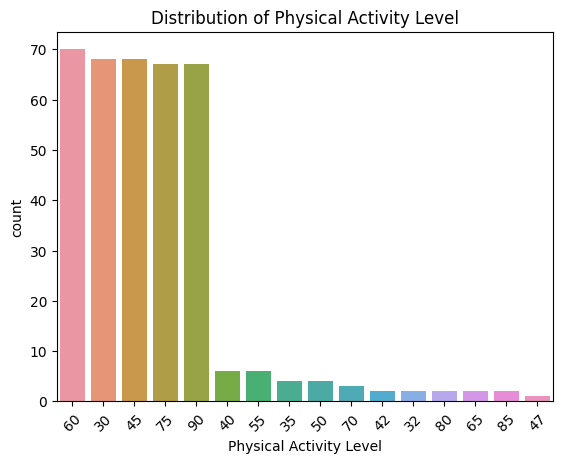

In [17]:
sns.countplot(x='Physical Activity Level', 
              data=sleep_df, 
              order=sleep_df['Physical Activity Level'].value_counts().index
             )
plt.title('Distribution of Physical Activity Level')
plt.xticks(rotation=45)
plt.show()

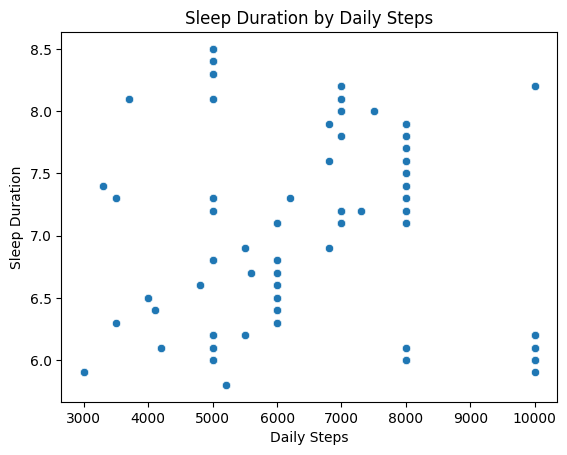

In [18]:
sns.scatterplot(x='Daily Steps', y='Sleep Duration', data=sleep_df)
plt.title('Sleep Duration by Daily Steps')
plt.show()

In [19]:
fig = px.pie(sleep_df, 
             names='Stress Level', 
             title='Distribution of Stress Level')
fig.show()

In [20]:
fig = px.bar(sleep_df, 
             x='Stress Level', 
             y='Quality of Sleep', 
             color='Stress Level',
             title='Relationship between Stress Level and Quality of Sleep'
            )
fig.show()

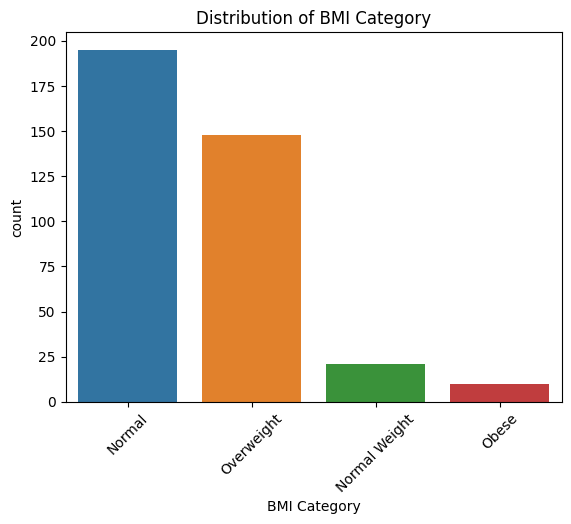

In [21]:
sns.countplot(x='BMI Category', 
              data=sleep_df, 
              order=sleep_df['BMI Category'].value_counts().index
             )
plt.title('Distribution of BMI Category')
plt.xticks(rotation=45)
plt.show()

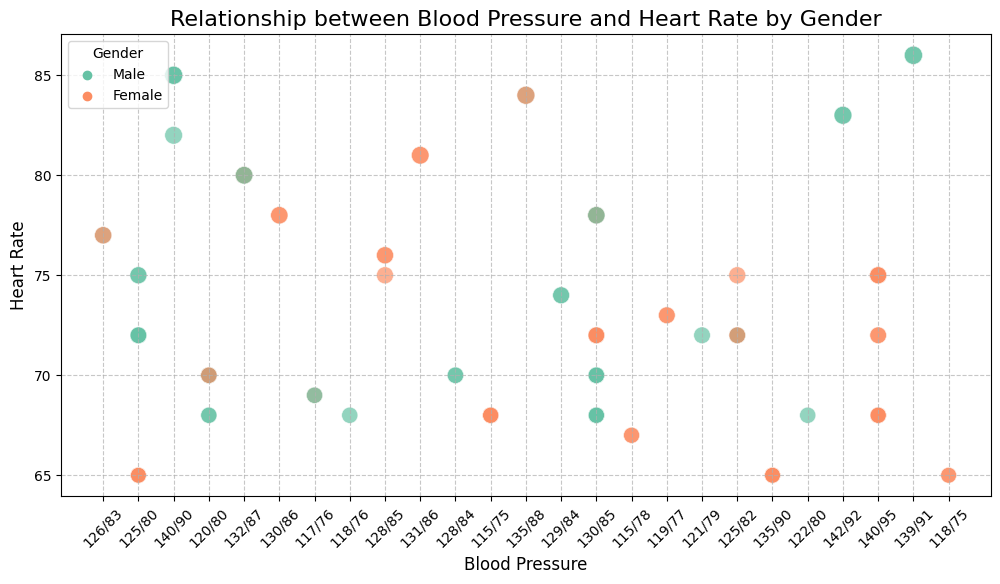

In [22]:
plt.figure(figsize=(12, 6))
scatter_plot = sns.scatterplot(x='Blood Pressure', 
                               y='Heart Rate', 
                               data=sleep_df, 
                               hue='Gender', 
                               palette='Set2', 
                               s=sleep_df['Heart Rate']*2,
                               edgecolor='w',
                               alpha=0.7, 
                               linewidth=0.5)

plt.xticks(rotation=45)

plt.title('Relationship between Blood Pressure and Heart Rate by Gender', fontsize=16)
plt.xlabel('Blood Pressure', fontsize=12)
plt.ylabel('Heart Rate', fontsize=12)
plt.legend(title='Gender', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()
